# 06 — Bring your Case information: review first, solve second

**Goal:** start from the information you actually have, make missing/assumed values visible, and only then run a bounded solver-backed example.

This lesson is intentionally different from a long CLI tour. Think of it as a small engineering workspace:

1. **Check the runtime** — CEPT + OpenDSS must be healthy.
2. **Paste Case information** — notes, values, or a summary of files you have.
3. **Review gaps** — choose `strict`, `assisted`, or `exploratory`; nothing is guessed silently.
4. **Optional agent bridge** — use OpenCode only if you want help organizing the intake; it never manufactures evidence.
5. **Run one bounded demo** — inspect the exact solver receipt. This demo does not depend on the agent bridge.

> **Claim boundary:** `WORKFLOW_VALIDATED` only. A passing notebook is not project validation, field validation, or PowerFactory agreement.


In [1]:
#@title Setup — run once, then read the results below
from hashlib import sha256
from urllib.request import urlopen

_bootstrap_url = "https://raw.githubusercontent.com/sarutesri/cept-studio-edu/main/public/notebooks/_lesson.py"
_bootstrap = urlopen(_bootstrap_url, timeout=60).read()
if sha256(_bootstrap).hexdigest() != "fd7df585358a9e127d0976f9a804e3c4cb30ce5c07c5ff1b0c38e3af19233d72":
    raise ValueError("Lesson helper hash mismatch")
exec(compile(_bootstrap, "cept-lesson", "exec"), globals())


CEPT_WHEEL_URL not supplied; using the existing installed environment.
CLI: cept --version


cept-power-studio 0.2.0.dev0
Lesson helpers ready. Stage cells below run the same CEPT commands as a normal terminal.


## Step 0 — Check CEPT like a terminal user

Run the same commands you would use outside Colab. The leading ! only tells Colab to execute a shell command; remove it in a normal terminal.

In [2]:
!cept capability show --format text

CEPT studies you can try
----------------------------
Teaching examples (not project approval)
  Fault study (OpenDSS)
  Hosting capacity (OpenDSS)
  Load flow (OpenDSS)
  Unbalanced load flow (OpenDSS)

What this means
  These are solver-backed teaching examples.
  They do NOT approve a real project or field installation.

Next
  cept environment check --format text


### Is the teaching environment ready?

`environment check` performs the installed OpenDSS trial solve. Keep this ready before working on Case information.

In [3]:
!cept environment check --format text

CEPT environment check: READY
-----------------------------
Solver             OpenDSS (ready)
Version            OpenDSS 0.14.5

What this means
  CEPT and OpenDSS are installed and can run a teaching study.
  This checks the teaching environment, not a real electrical system.

Next
  cept capability show --format text


## Step 1 — Paste the Case information you have

Edit only the box below. It may be incomplete. In a real project the same idea can start from several local files (notes, CSV/Excel, JSON/YAML, manuals, figures, or model files). The full CEPT/OpenCode front desk uses deterministic readers first and normalizes the rest into the canonical Case intake.

Choose a review policy:

| Policy | What it allows |
| --- | --- |
| `strict` | source/derived values only |
| `assisted` | may use a **named documented default** after your explicit approval |
| `exploratory` | may also use an **AI-selected assumption** after your explicit approval; demonstrator only |

Every policy blocks unresolved required inputs. Research work stays source-backed.


In [4]:
POLICY = "assisted"  # strict | assisted | exploratory
CASE_INFO = """
11 kV feeder
Transformer rating: 5 MVA
Load: approximately 3 MW
PV: 1 MW
Transformer impedance: not available yet
""".strip()
Path("case-info.txt").write_text(CASE_INFO + "\n", encoding="utf-8")
print("Your case information is saved")
print("------------------------------")
print(f"Review policy: {POLICY}")
print("Saved to: case-info.txt")
print("Next: review what is known and missing below")


Your case information is saved
------------------------------
Review policy: assisted
Saved to: case-info.txt
Next: review what is known and missing below


## Step 2 — Review what is known and what is missing

The next cell creates a **review ledger**, not a solver Case. Notice that the missing transformer impedance stays `unresolved`; no typical value is inserted silently.


In [5]:
resolution_payload = {
    "schema": "cept-case-info-resolution-v1",
    "policy": POLICY,
    "items": [
        {"field": "network.nominal_kv", "status": "source", "value": 11.0, "source_ref": "case-info.txt"},
        {"field": "transformer.rating_mva", "status": "source", "value": 5.0, "source_ref": "case-info.txt"},
        {"field": "load.p_mw", "status": "source", "value": 3.0, "source_ref": "case-info.txt"},
        {"field": "pv.p_mw", "status": "source", "value": 1.0, "source_ref": "case-info.txt"},
        {"field": "transformer.impedance_pu", "status": "unresolved"},
    ],
    "notes": ["Teaching intake only; no user Case has been solved."],
}
_ = Path("case-info-resolution.json").write_text(
    json.dumps(resolution_payload, indent=2) + "\n",
    encoding="utf-8",
)
print("Review list saved to case-info-resolution.json")


Review list saved to case-info-resolution.json


### Validate the ledger, then read the verdict

The typed contract decides what blocks a user-case solve. An older wheel without the contract type still shows the same verdict from raw statuses.


In [6]:
schema_status = "available"
try:
    from cept.schema import CaseInfoResolutionLedger
    ledger = CaseInfoResolutionLedger.model_validate(resolution_payload)
    blockers = ledger.blockers(research=False)
except ImportError:
    schema_status = "upgrade wheel for typed validation"
    blockers = [item for item in resolution_payload["items"] if item["status"] == "unresolved"]
known = len(resolution_payload["items"]) - len(blockers)
missing_names = []
for blocker in blockers:
    field = getattr(blocker, "field", None)
    if field is None and isinstance(blocker, dict):
        field = blocker.get("field")
    missing_names.append(str(field or blocker))
print("Case information review - BLOCKED (this is expected)")
print("----------------------------------------------------")
print(f"Policy        {POLICY}")
print(f"Known         {known} of {len(resolution_payload['items'])} (from case-info.txt)")
print(f"Missing       {len(blockers)}: {', '.join(missing_names)}")
print("Why it matters: the transformer impedance sets the voltage drop,")
print("  so CEPT will not solve your case until it is provided or approved.")
print(f"Ledger check  {schema_status}")
print()
print("Next")
print("  add the missing value from a source, or explicitly approve a fallback,")
print("  then review again before solving")
assert blockers, "the teaching intake intentionally keeps transformer impedance unresolved"


Case information review - BLOCKED (this is expected)
----------------------------------------------------
Policy        assisted
Known         4 of 5 (from case-info.txt)
Missing       1: transformer.impedance_pu
Why it matters: the transformer impedance sets the voltage drop,
  so CEPT will not solve your case until it is provided or approved.
Ledger check  available

Next
  add the missing value from a source, or explicitly approve a fallback,
  then review again before solving


### What should happen next?

For `transformer.impedance_pu`, a good assistant should first suggest where to get the value: transformer nameplate/test report, manufacturer datasheet, utility model, or the original network model.

If you deliberately want a demonstrator instead:

- in **assisted** mode, only choose a documented default that has an identifiable source/version and explicitly approve it;
- in **exploratory** mode, you may explicitly let AI choose a placeholder, but the ledger must say `ai_selected_assumption`, record the reason, and keep `approved_by_user: true`;
- neither choice becomes measured/project evidence.


## Step 3 — Optional OpenCode bridge

The researcher-facing TUI surface is still /cept; there is no separate notebook agent UX. The bridge is optional: the bounded solver demo below runs without OpenCode, a provider key, or any agent command.

If you choose to use it, ask /cept to review the Case information, explain unresolved required fields, and stop before the solver. Keep this cell collapsed and do not add a provider key unless you intentionally want to try the bridge.

In [7]:
#@title Advanced — OpenCode provider bridge (optional)
AGENT_COMMAND = r'''---
description: Review Case information without inventing engineering evidence
---
Work only in the current teaching workspace. Review the learner objective plus case-info.txt and case-info-resolution.json. Accept mixed local source formats as intake evidence, but never pretend every format has a deterministic CEPT parser. Use source, derived, unresolved, documented_default, and ai_selected_assumption exactly. Never infer approval from silence. strict allows source/derived only; assisted may use an explicitly approved named default; exploratory may also use an explicitly approved AI-selected demonstrator assumption. If anything required remains unresolved, explain what is missing, why it matters, where to obtain it, and stop before the solver. CEPT Public uses noun+verb CLI; never invent commands. WORKFLOW_VALIDATED is not PROJECT_VALIDATED.

$ARGUMENTS
'''

def _colab_secret():
    names = ('OPENAI_API_KEY', 'ANTHROPIC_API_KEY')
    for name in names:
        if os.environ.get(name, '').strip():
            return name
    try:
        from google.colab import userdata
    except ImportError:
        return ''
    for name in names:
        try:
            value = (userdata.get(name) or '').strip()
        except Exception:
            continue
        if value:
            os.environ[name] = value
            return name
    return ''

def review_with_opencode():
    in_colab = 'google.colab' in sys.modules or bool(os.environ.get('COLAB_RELEASE_TAG'))
    key_name = _colab_secret() if in_colab else ''
    if not in_colab or not key_name:
        print('Optional agent: skipped outside interactive Colab or without a configured provider key.')
        return None
    opencode = Path.home() / '.opencode' / 'bin' / 'opencode'
    if not opencode.is_file():
        subprocess.run('curl -fsSL https://opencode.ai/install | bash', shell=True, check=True)
    command_dir = Path.cwd() / '.opencode' / 'commands'
    command_dir.mkdir(parents=True, exist_ok=True)
    (command_dir / 'cept.md').write_text(AGENT_COMMAND, encoding='utf-8')
    prompt = f'Review my Case information using policy {POLICY}. Do not run a user-case solver while required inputs are unresolved.'
    completed = subprocess.run([str(opencode), 'run', '--command', 'cept', prompt], text=True, capture_output=True, check=False)
    print(completed.stdout)
    if completed.returncode != 0:
        raise RuntimeError(completed.stderr.strip() or 'OpenCode review failed')
    return completed.stdout

AGENT_REVIEW = review_with_opencode()

Optional agent: skipped outside interactive Colab or without a configured provider key.


## Step 4 — Run one bounded solver-backed demonstration

The learner Case above is still BLOCKED, so CEPT does not solve it. The commands below run and verify the bundled IEEE13 demo instead. They are ordinary CEPT terminal commands; the PASS belongs only to that demo.

In [8]:
!cept study demo load-flow \
    --network ieee13 \
    --out runs/06-bounded-load-flow \
    --force \
    --format text

!cept study verify runs/06-bounded-load-flow --format text

CEPT study result: FINISHED
----------------------------
Result             Finished the balanced load flow and saved the evidence
Saved run          runs\06-bounded-load-flow
Case fingerprint   748c8026c9d6 (matches the case you ran)

What this means
  The study completed and saved solver-backed evidence.
  It does NOT approve a real project or field installation.

Next
  cept study verify runs\06-bounded-load-flow --format text


CEPT study check: PASSED
----------------------------
Study              Load flow (OpenDSS)
Case fingerprint   748c8026c9d6 (matches the case you ran)

Checked   3 groups, 14 checks, all passed
  [PASS] Case identity (4 checks)
  [PASS] Solver result (3 checks)
  [PASS] Saved evidence (7 checks)

What this means
  The saved result matches its Case, solver run, and saved evidence.
  It does NOT approve a real project or field installation.

Saved evidence     public-verification.json

For the full check list
  cept study verify . --format json


In [9]:
#@title Checks - bounded demo receipt (advanced)
verification = read(WORKSPACE / "runs" / "06-bounded-load-flow" / "public-verification.json")
assert verification["passed"] is True
assert verification["claim"] == "WORKFLOW_VALIDATED"
assert verification["study_type"] == "load_flow"
assert verification["engine"] == "opendss"
print("Lesson check: PASSED")
print("The bundled IEEE 13-node demo solved and its evidence matches.")
print("This says nothing about your incomplete case above, which stays blocked.")


Lesson check: PASSED
The bundled IEEE 13-node demo solved and its evidence matches.
This says nothing about your incomplete case above, which stays blocked.


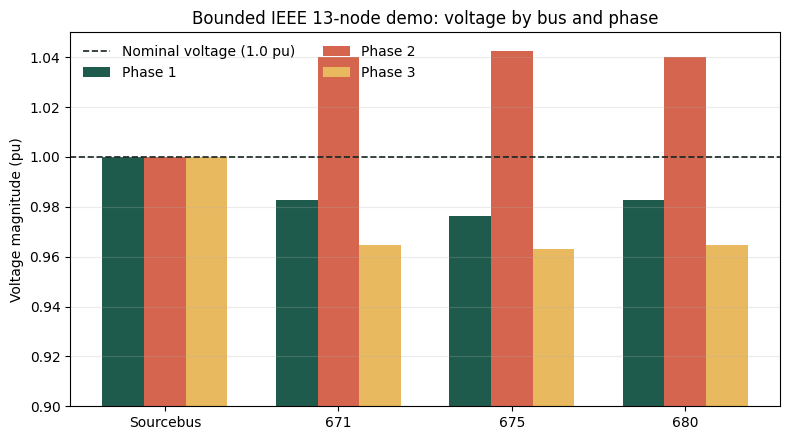

In [10]:
#@title Plot — bounded demo voltage by phase
import matplotlib.pyplot as plt

bounded_results = read(WORKSPACE / "runs" / "06-bounded-load-flow" / "results.json")
bounded_rows = bounded_results["load_flow"]["bus_voltages"]
plot_buses = ["sourcebus", "671", "675", "680"]
phase_values = {
    phase: [
        next(float(row["v_pu"]) for row in bounded_rows if row["bus"].lower() == bus and row["phase"] == phase)
        for bus in plot_buses
    ]
    for phase in (1, 2, 3)
}
assert all(len(values) == len(plot_buses) for values in phase_values.values())
x = list(range(len(plot_buses)))
width = 0.24
fig, ax = plt.subplots(figsize=(8, 4.5))
for offset, phase, color in [(-width, 1, "#1f5b4d"), (0, 2, "#d5654e"), (width, 3, "#e9b95f")]:
    ax.bar([value + offset for value in x], phase_values[phase], width, label=f"Phase {phase}", color=color)
ax.axhline(1.0, color="#17231f", linestyle="--", linewidth=1.2, label="Nominal voltage (1.0 pu)")
ax.set_xticks(x)
ax.set_xticklabels([bus.title() for bus in plot_buses])
ax.set_title("Bounded IEEE 13-node demo: voltage by bus and phase")
ax.set_ylabel("Voltage magnitude (pu)")
ax.set_ylim(0.90, 1.05)
ax.legend(frameon=False, ncol=2)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
from IPython.display import display
display(fig)
plt.close(fig)


## What to take away

- **Flexible input does not mean flexible truth.** OpenCode may organize messy information, but everything must converge on one canonical typed Case.
- **Missing stays missing** until you provide evidence or explicitly approve an allowed demonstrator fallback.
- **Default and AI-selected are different.** A documented default is named/versioned; an AI-selected assumption is model judgement. Both must stay visible.
- **Solver truth stays separate.** The final PASS above belongs to the bundled IEEE13 demo, not to the incomplete Case information in this notebook.

### Try it

Replace `CASE_INFO` with your own short description. Keep one important field missing and see whether your review remains blocked. Then add the real value from a source and update its ledger status to `source`.
